286.64503821467594


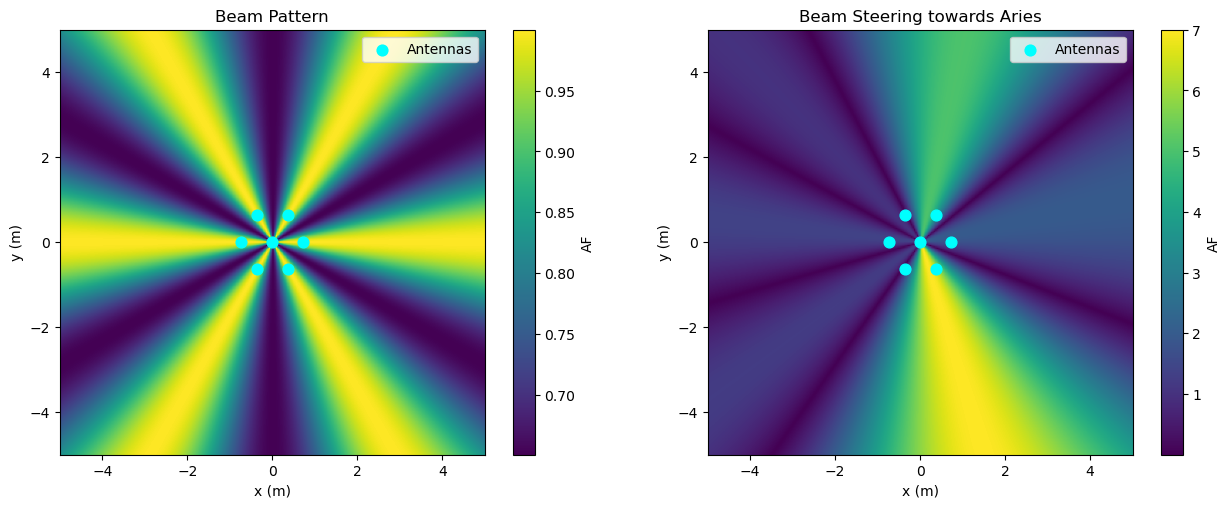

In [75]:
import numpy as np
import matplotlib.pyplot as plt

c = 3e8
f = 206.5e6
lam = c/f
k = 2*np.pi/lam
R = lam/2

theta_aries = np.deg2rad(np.degrees(np.arctan2(-2.91, 0.87)) + 360)
print(np.rad2deg(theta_aries))

tx_positions = np.array([
    [0, 0],                                   
    [ R, 0],
    [ R/2,  np.sqrt(3)*R/2],
    [-R/2,  np.sqrt(3)*R/2],
    [-R, 0],
    [-R/2, -np.sqrt(3)*R/2],
    [ R/2, -np.sqrt(3)*R/2],
])


def steering_vector(theta):
    x = tx_positions[:,0]
    y = tx_positions[:,1]
    
    return np.exp(-1j * k * (x*np.cos(theta) + y*np.sin(theta)))
  

w_unsteered = np.ones(7)
w_steered   = np.conj(steering_vector(theta_aries))


def factor(weights, X, Y):

    AF = np.zeros_like(X, dtype=complex)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):

            theta = np.arctan2(Y[i,j], X[i,j])

            v = steering_vector(theta)

            AF[i,j] = np.dot(weights, v)

    return np.abs(AF)


x = np.linspace(-5,5,300)
y = np.linspace(-5,5,300)

X,Y = np.meshgrid(x,y)

AF_un = factor(w_unsteered, X, Y)
AF_st = factor(w_steered,   X, Y)



plt.figure(figsize=(13,5))


plt.subplot(1,2,1)
plt.imshow(AF_un, extent=[-5,5,-5,5],
           origin='lower')
plt.colorbar(label="AF")
plt.scatter(tx_positions[:,0], tx_positions[:,1],
            c='cyan', s=60, label='Antennas')
plt.title("Beam Pattern")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.legend()


plt.subplot(1,2,2)
plt.imshow(AF_st, extent=[-5,5,-5,5],
           origin='lower')
plt.colorbar(label='AF')
plt.scatter(tx_positions[:,0], tx_positions[:,1],
            c='cyan', s=60, label='Antennas')
plt.title("Beam Steering towards Aries")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.legend()

plt.tight_layout()
plt.show()


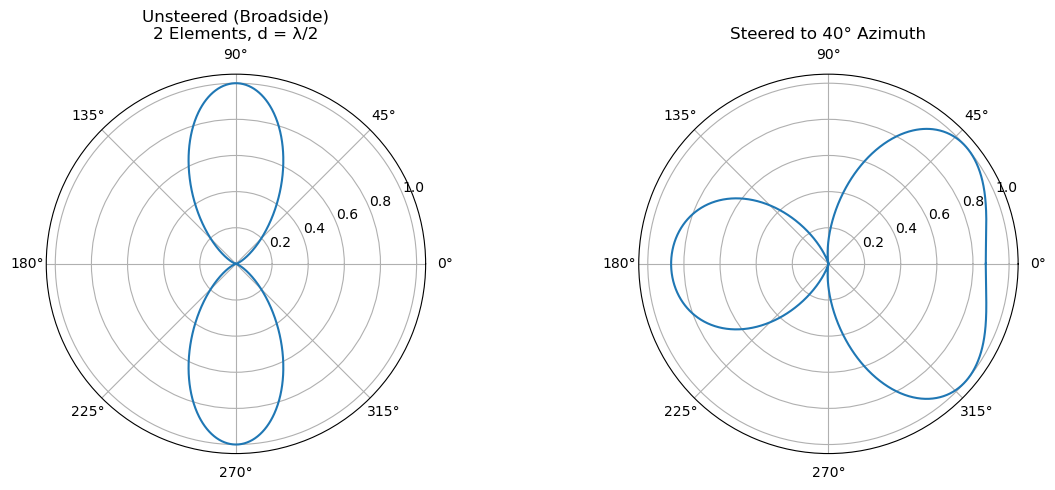

In [377]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
c = 3e8
f = 206.5e6
lam = c / f
k = 2 * np.pi / lam
d = lam / 2

# Azimuth range
phi = np.linspace(0, 2*np.pi, 2000)

# -------------------------
# 1) UNSTEERED (Broadside)
# -------------------------
AF_unsteered = 1 + np.exp(1j * k * d * np.cos(phi))
P_unsteered = np.abs(AF_unsteered)**2
P_unsteered /= np.max(P_unsteered)

# -------------------------
# 2) STEERED to 40 degrees
# -------------------------
phi0 = np.deg2rad(40)

AF_steered = 1 + np.exp(1j * k * d * (np.cos(phi) - np.cos(phi0)))
P_steered = np.abs(AF_steered)**2
P_steered /= np.max(P_steered)

# -------------------------
# PLOTS
# -------------------------
plt.figure(figsize=(12,5))

# Unsteered
plt.subplot(1,2,1, projection='polar')
plt.plot(phi, P_unsteered)
plt.title("Unsteered (Broadside)\n2 Elements, d = λ/2")

# Steered
plt.subplot(1,2,2, projection='polar')
plt.plot(phi, P_steered)
plt.title("Steered to 40° Azimuth")

plt.tight_layout()
plt.show()